# EDA on Boston Housing  v.ekc-c

A guided, hands-on EDA using the **Boston Housing dataset** — a classic dataset for studying what drives housing prices.  
You'll use Seaborn and Matplotlib together to uncover patterns, spot problems, and tell a data story.

| Section | Topic |
|---------|-------|
| 1 | Setup & Dataset Overview |
| 2 | Seaborn EDA Tools Warm-Up |
| 3 | EDA — Descriptive Statistics |
| 4 | EDA — Data Quality |
| 5 | EDA — Visualization (scatterplots, heatmap, pairplot, boxplot) |
| 6 | Open Exploration |
| Appendix | EDA Checklist |


---
## 1. Setup & Dataset Overview

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import warnings
warnings.filterwarnings('ignore')


In [23]:
data = pd.read_csv('BostonHousingData.csv')
data.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


### Boston Housing Features

| Column | Description |
|--------|-------------|
| `CRIM` | Per-capita crime rate |
| `ZN` | % residential land zoned for large lots |
| `INDUS` | % non-retail business acres |
| `CHAS` | Charles River dummy (1 = borders river) |
| `NOX` | Nitric oxide concentration (pollution) |
| `RM` | Average rooms per dwelling |
| `AGE` | % owner-occupied units built before 1940 |
| `DIS` | Weighted distance to employment centers |
| `RAD` | Accessibility to radial highways |
| `TAX` | Full-value property-tax rate |
| `PTRATIO` | Pupil-teacher ratio |
| `B` | 1000(Bk - 0.63)² (a demographic index) |
| `LSTAT` | % lower-status population |
| `MEDV` | **Median home value ($000s) — target variable** |

**See full details:** [Toronto CS documentation](https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html)


### First Look

Before doing any visualizations, answer these questions with code:
1. How many rows and columns? Any immediately obvious issues?
2. What are the data types of each column?
3. Are there any surprising min/max values in `.describe()`?

*(double-click the cell below to record your observations)*


In [3]:
# data.shape, data.dtypes, data.describe()


**Observations:** *(double-click to edit)*

*Your notes here*

---
## 2. Seaborn EDA Tools Warm-Up

Quick refresher on the three key EDA plots from last class.

### 📋 Board Reference

| Tool | When to use it |
|------|---------------|
| `sns.pairplot(df)` | Quick overview — all numeric pairs at once |
| `sns.boxplot(x='cat', y='num')` | Distribution of a numeric var across categories; shows outliers |
| `sns.heatmap(df.corr(), annot=True)` | Correlation strength between all numeric pairs |


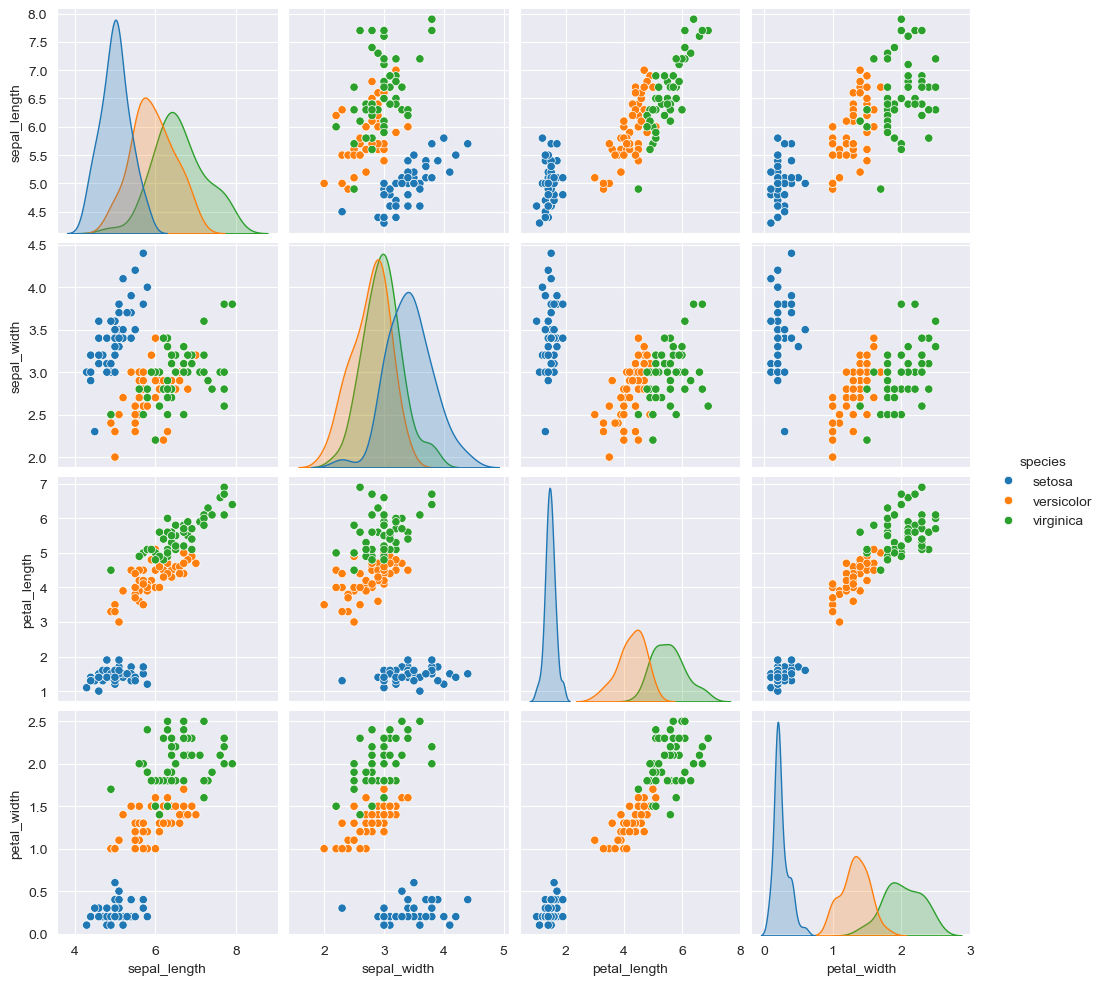

In [4]:
# pairplot refresher — iris (fast, few columns)
iris = sns.load_dataset('iris')
sns.pairplot(iris, hue='species')
plt.show()


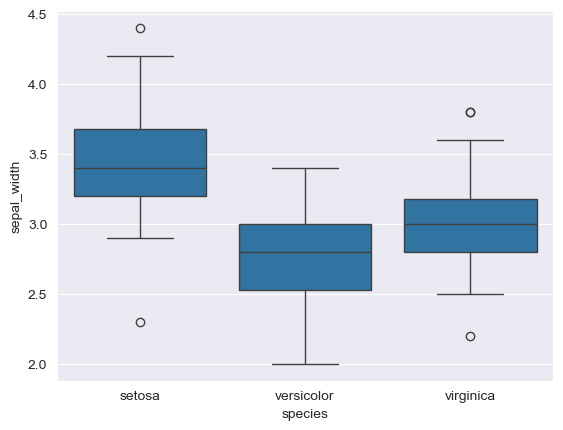

In [5]:
# boxplot refresher
sns.boxplot(data=iris, x='species', y='sepal_width')
plt.show()


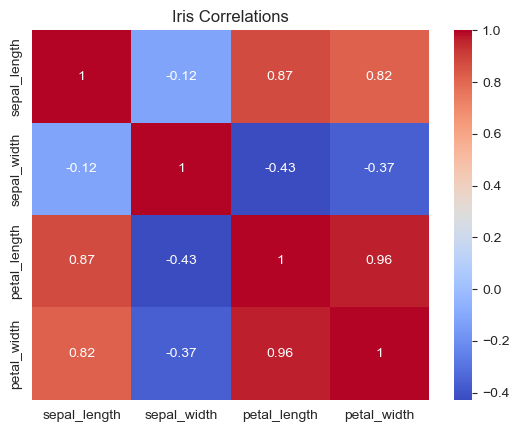

In [6]:
# heatmap refresher
corrmat = iris.corr(numeric_only=True)
sns.heatmap(corrmat, annot=True, cmap='coolwarm')
plt.title('Iris Correlations')
plt.show()


---
## 3. EDA — Descriptive Statistics

Now shift focus to the Boston data.


### 🔬 Explore 1 — Describe the Data

1. Run `data.describe()` — look at **mean**, **min**, and **max** for each column.  
   Do any values seem unrealistic or suspicious?

2. Check the mean of each column — which features vary the most (high std)?  
   Use `data.describe().loc['std']` and sort it.

3. Look at `CHAS` — it's a binary dummy variable (0 or 1).  
   How many homes border the river? Use `.value_counts()`.


In [7]:
# 1. data.describe()


In [8]:
# 2. Sort columns by std dev


In [9]:
# 3. data['CHAS'].value_counts()


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
# 1. Descriptive stats
print(data.describe())

# 2. Most variable columns
print(data.describe().loc['std'].sort_values(ascending=False))

# 3. River bordering homes
print(data['CHAS'].value_counts())
print(f"{data['CHAS'].sum()} homes border the Charles River ({data['CHAS'].mean()*100:.1f}%)")
```

</details>

---
## 4. EDA — Data Quality

### 📋 Board Reference — Quality Checks

```python
df.isna().sum()          # nulls per column
df.duplicated().sum()    # duplicate rows
df.dtypes                # data types
```


### 🔬 Explore 2 — Quality Check

1. Are there any null values? Which columns?
2. Are there any duplicate rows?
3. Are all data types numeric (as expected for this dataset)?

*(Note your findings below the code)*


In [10]:
# 1. isna check


In [11]:
# 2. duplicated check


In [12]:
# 3. dtypes check


**Quality notes:** *(double-click to edit)*

*Your findings here*

<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
# 1. Null values
print("Nulls per column:")
print(data.isna().sum())

# 2. Duplicates
print(f"\nDuplicate rows: {data.duplicated().sum()}")

# 3. Data types
print("\nData types:")
print(data.dtypes)
```

</details>

---
## 5. EDA — Visualization

### 📋 Board Reference — Which plot when?

| Question | Plot type |
|----------|-----------|
| How does each feature relate to price? | Scatter (x=feature, y=MEDV) |
| Which features are most correlated? | Heatmap |
| Are there outliers in a feature? | Boxplot |
| How is price distributed? | Histogram / KDE |


### 🔬 Explore 3 — Scatterplots Grid

The code below creates a 2×7 grid of scatterplots — all features vs `MEDV` (price).  
**Run it, then answer the questions below.**


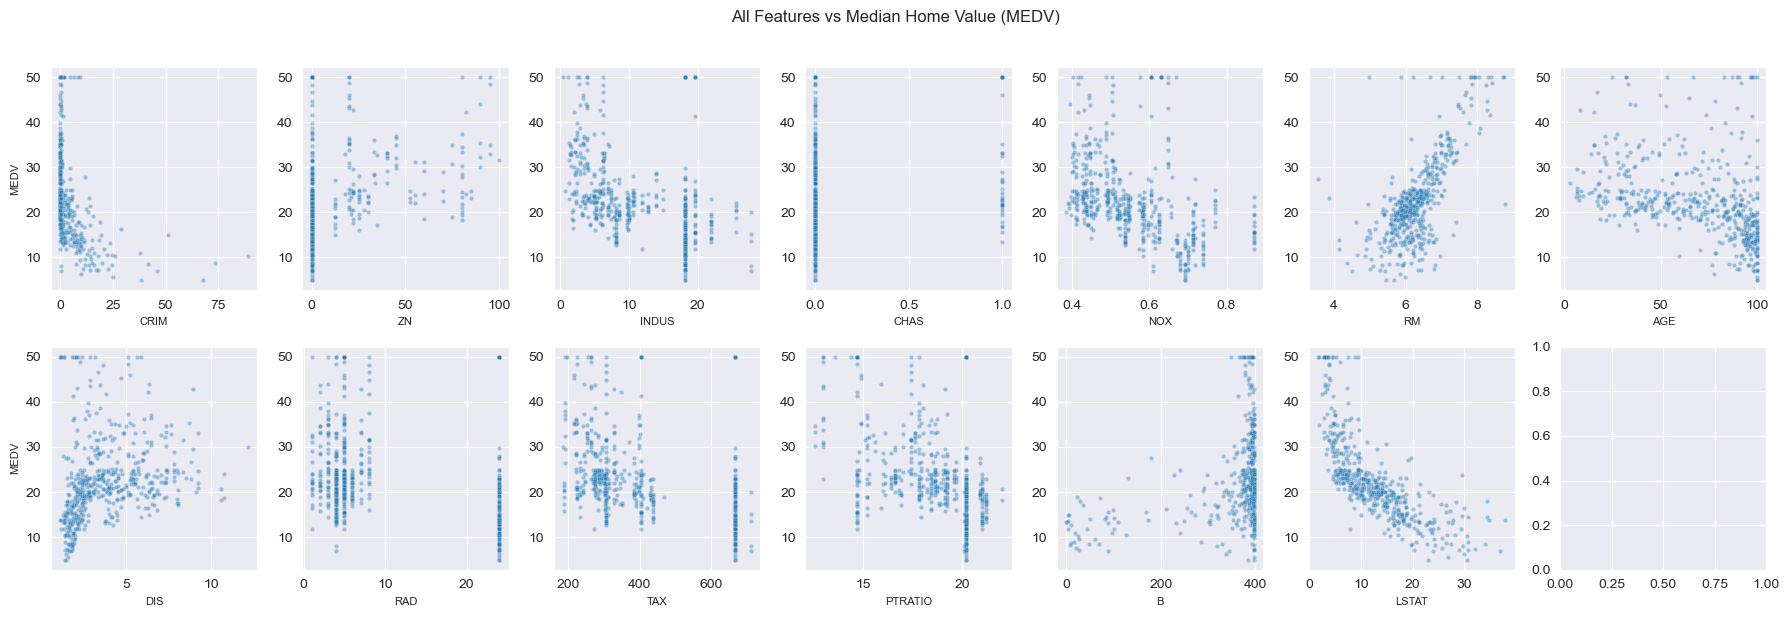

In [13]:
# 2x7 grid: every feature vs MEDV
feature_cols = [c for c in data.columns if c != 'MEDV']
rows, cols = 2, 7
fig, axes = plt.subplots(rows, cols, figsize=(18, 6))

for idx, col in enumerate(feature_cols):
    ax = axes[idx // cols][idx % cols]
    sns.scatterplot(data=data, x=col, y='MEDV', ax=ax, alpha=0.4, s=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('MEDV' if idx % cols == 0 else '', fontsize=8)

plt.suptitle('All Features vs Median Home Value (MEDV)', y=1.02)
plt.tight_layout()
plt.show()


**Which features look most related to MEDV?** *(double-click to edit)*

*Your answer here*

### 🔬 Explore 4 — Correlation Heatmap

1. Compute the full correlation matrix and display it as a heatmap (with `annot=True`).
2. Which features have correlation > 0.5 with `MEDV`?  
   Use: `abs(corrmat['MEDV']) > 0.5`
3. Make a **pairplot** of only the highly correlated features (including `MEDV`).  
   What do you see?


In [14]:
# 1. Full correlation heatmap


In [15]:
# 2. Filter: which columns correlate > 0.5 with MEDV?


In [16]:
# 3. Pairplot of correlated features only


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*RM (rooms) has the strongest positive correlation with price. LSTAT (% lower status) has the strongest negative correlation.*

```python
# 1. Full heatmap
corrmat = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corrmat, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Boston Housing Correlations')
plt.tight_layout()
plt.show()

# 2. Which correlate strongly with MEDV?
strong_corr = corrmat.index[abs(corrmat['MEDV']) > 0.5]
print("Features with |r| > 0.5 with MEDV:", list(strong_corr))

# 3. Pairplot of correlated subset
corr_data = data[strong_corr]
sns.pairplot(corr_data)
plt.suptitle('Highly Correlated Features with MEDV', y=1.02)
plt.tight_layout()
plt.show()
```

</details>

### 🔬 Explore 5 — Distributions & Boxplots

1. Make a **boxplot** of all columns in `data` (just `sns.boxplot(data)`).  
   Do the scales look problematic? Why?

2. Make a **boxplot** comparing `MEDV` by `CHAS` (river vs. no river).  
   Do river-adjacent homes cost more?

3. Make a **histogram** of `MEDV`. Does the distribution look normal?  
   Any unusual values at the high end?


In [17]:
# 1. Boxplot of all columns


In [18]:
# 2. MEDV by CHAS


In [19]:
# 3. Histogram of MEDV


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*Notice the spike at MEDV=50 — this is likely a data cap (values were censored at $50,000).*

```python
# 1. All columns boxplot — different scales make this messy
plt.figure(figsize=(12, 4))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title('All Feature Distributions (Note: mixed scales!)')
plt.tight_layout()
plt.show()

# 2. MEDV by river adjacency
sns.boxplot(x='CHAS', y='MEDV', data=data)
plt.xlabel('Borders Charles River (1=Yes)')
plt.ylabel('Median Home Value ($000s)')
plt.title('Home Value by River Adjacency')
plt.show()

# 3. MEDV histogram
sns.histplot(data=data, x='MEDV', bins=30, kde=True)
plt.title('Distribution of Median Home Value')
plt.xlabel('Median Home Value ($000s)')
plt.show()
```

</details>

---
## 6. Open Exploration

Pick **one surprising finding** from your EDA above and dig deeper into it.  
Some ideas:

- Zoom in on high-crime neighborhoods — how do they differ on other features?
- Look at homes near the river vs. not — are there other differences beyond price?
- Filter to only homes with more than 6 rooms and compare to those with fewer.
- What's the most unusual row in the dataset? (hint: try `.nlargest()` or `.nsmallest()`)


In [20]:
# Your investigation here


In [21]:
# Visualization to support your finding


**What did you find?** *(double-click to edit)*

*Your story here*

---
## Appendix — EDA Checklist

**Step 1 — Inspect**
- `df.head()`, `df.shape`, `df.info()`, `df.describe()`

**Step 2 — Data Quality**
- `df.isna().sum()` · `df.duplicated().sum()` · `df.dtypes`

**Step 3 — Univariate (one variable at a time)**
- `sns.histplot(df, x='col', kde=True)` — distribution shape
- `sns.boxplot(data=df)` — outliers

**Step 4 — Bivariate (pairs of variables)**
- `sns.scatterplot(x='feature', y='target')` — relationship
- `sns.boxplot(x='cat', y='num')` — numeric by category
- `corrmat = df.corr(numeric_only=True); sns.heatmap(corrmat, annot=True)`

**Step 5 — Multivariate**
- `sns.pairplot(df[selected_cols])` — subset of key columns
- `sns.FacetGrid + .map(...)` — conditional distributions

**Always ask:**
- Which variables predict the target?
- Are there outliers or data quality issues?
- What's the story the data is telling?
